# Molecular Solubility Analysis
## Project Objective
The aim of this project is to analyze molecular properties and investigate the factors that affect aqueous solubility. This project will be developed step by step using Python and will later include cheminformatics and machine learning techniques.

In [1]:
import pandas as pd

### Preview the Dataset
'df.head()' displays the first 5 rows of the dataset by default.

It is useful for quickly inspecting:
-Column names
-Example values
-General structure of the dataset

In [2]:
#data seti okur
df = pd.read_csv("data/delaney-processed.csv")

df.head(5)


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


## 1. Dataset Overview
In this section, we will explore the structure and basic characteristics of the dataset.

### Dataset Dimensions

`df.shape` returns the dimensions of the DataFrame in the following format:

(rows, columns)

- Rows represent the observations (molecules).
- Columns represent the variables/features.

In [3]:
df.shape

(1128, 10)

**Observation:** The dataset contains 1,128 molecules and 10 columns.

### Column Names

`df.columns` returns the names of all columns in the DataFrame.

This helps us understand which variables are available for analysis.

In [4]:
df.columns

Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='str')

### Dataset Information

`df.info()` provides a summary of the DataFrame, including:

- Column names
- Number of non-null values
- Data types
- Memory usage

Common data types:

- `str` → text
- `int64` → integer numbers
- `float64` → decimal numbers

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 10 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Compound ID                                      1128 non-null   str    
 1   ESOL predicted log solubility in mols per litre  1128 non-null   float64
 2   Minimum Degree                                   1128 non-null   int64  
 3   Molecular Weight                                 1128 non-null   float64
 4   Number of H-Bond Donors                          1128 non-null   int64  
 5   Number of Rings                                  1128 non-null   int64  
 6   Number of Rotatable Bonds                        1128 non-null   int64  
 7   Polar Surface Area                               1128 non-null   float64
 8   measured log solubility in mols per litre        1128 non-null   float64
 9   smiles                                   

**Observation:** All columns contain 1,128 non-null values, suggesting that there are no missing values in the dataset.

### Summary Statistics

`df.describe()` provides descriptive statistics for numerical columns.

- `count` → Number of observations
- `mean` → Average value
- `std` → Standard deviation
- `min` → Minimum value
- `25%` → First quartile (Q1)
- `50%` → Median (Q2)
- `75%` → Third quartile (Q3)
- `max` → Maximum value

In [6]:
df.describe().round(2)

,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00
mean,-2.99,1.06,203.94,0.70,1.39,2.18,34.87,-3.05
std,1.68,0.24,102.74,1.09,1.32,2.64,35.38,2.10
min,-9.70,0.00,16.04,0.00,0.00,0.00,0.00,-11.60
25%,-3.95,1.00,121.18,0.00,0.00,0.00,0.00,-4.32
50%,-2.87,1.00,182.18,0.00,1.00,1.00,26.30,-2.86
75%,-1.84,1.00,270.37,1.00,2.00,3.00,55.44,-1.60
max,1.09,2.00,780.95,11.00,8.00,23.00,268.68,1.58


**Observation:** The mean molecular weight 203 is higher than the median 182, suggesting that the molecular weight distribution may be right-skewed due to some high molecular weight compounds.

## 2. Data Quality & Cleaning

In this section, we will check the dataset for missing values, duplicate records, and potential data quality issues.

### Missing Values

Missing values are data points that are absent from the dataset.

#### Check all columns

`df.isnull().sum()` checks the number of missing values in each column.

- `isnull()` → Returns `True` if a value is missing and `False` otherwise.
- `sum()` → Counts the `True` values in each column.

#### Check a single column

`df["Column Name"].isnull().sum()` checks the number of missing values in only the selected column.

In [7]:
df.isnull().sum()

Compound ID                                        0
ESOL predicted log solubility in mols per litre    0
Minimum Degree                                     0
Molecular Weight                                   0
Number of H-Bond Donors                            0
Number of Rings                                    0
Number of Rotatable Bonds                          0
Polar Surface Area                                 0
measured log solubility in mols per litre          0
smiles                                             0
dtype: int64

In [8]:
df["Minimum Degree"].isnull().sum()

np.int64(0)

**Observation:** No missing values were found in the dataset. The `Minimum Degree` column was also checked individually and contains no missing values.

### Duplicate Records

Duplicate records are rows that appear more than once in the dataset.

`df.duplicated().sum()` checks the total number of duplicate rows in the DataFrame.

- `duplicated()` → Checks each row and returns `True` if the row is a duplicate and `False` otherwise.
- `sum()` → Counts the `True` values.
- Therefore, the result shows the total number of duplicate rows in the dataset.

In [9]:
df.duplicated().sum()

np.int64(0)

**Observation:** No duplicate records were found in the dataset.

## 3. Exploratory Data Analysis

### Initial Hypothesis

The following molecular properties may influence aqueous solubility:

- Molecular Weight
- Polar Surface Area
- Number of H-Bond Donors
- Number of Rings
- Number of Rotatable Bonds

These relationships will be investigated through exploratory data analysis.

In [10]:
import matplotlib.pyplot as plt

### Molecular Weight Distribution

A histogram is used to visualize the distribution of a numerical variable.

In this section, we will examine the distribution of molecular weights in the dataset.

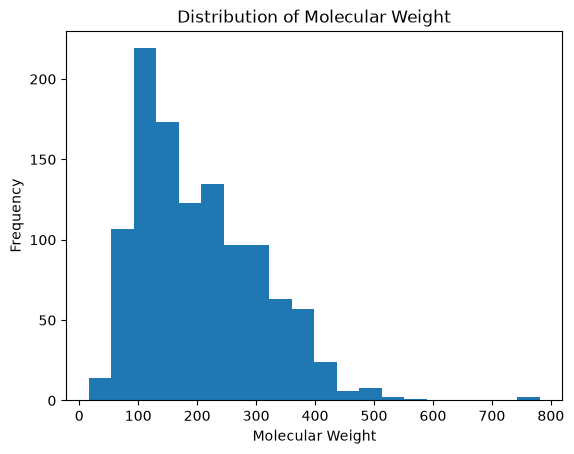

In [11]:
plt.hist(df["Molecular Weight"], bins=20)

plt.xlabel("Molecular Weight")
plt.ylabel("Frequency")
plt.title("Distribution of Molecular Weight")

plt.show()

**Observation:** The molecular weight distribution is right-skewed. Most compounds have relatively low to moderate molecular weights, while a smaller number of high-molecular-weight compounds form a long right tail. This is consistent with the mean molecular weight being higher than the median.

### Molecular Weight vs Solubility

A scatter plot is used to examine the relationship between two numerical variables.

Here, we investigate whether molecular weight is associated with measured aqueous solubility.

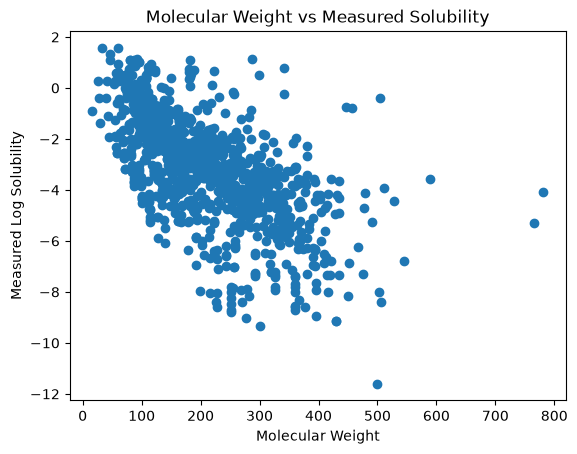

In [12]:
plt.scatter(
    df["Molecular Weight"],
    df["measured log solubility in mols per litre"]
)

plt.xlabel("Molecular Weight")
plt.ylabel("Measured Log Solubility")
plt.title("Molecular Weight vs Measured Solubility")

plt.show()

**Observation:** The scatter plot shows a negative relationship between molecular weight and measured log solubility. In general, compounds with higher molecular weights tend to have lower aqueous solubility. However, the considerable spread in the data suggests that molecular weight alone does not determine solubility and that other molecular properties also play an important role.

### Correlation Between Molecular Weight and Solubility

Correlation measures the strength and direction of the relationship between two numerical variables.

The correlation coefficient ranges from -1 to +1:

- `+1` → Strong positive relationship
- `0` → No linear relationship
- `-1` → Strong negative relationship

In [13]:
df["Molecular Weight"].corr(
    df["measured log solubility in mols per litre"]
)

np.float64(-0.6401894305424647)

**Observation:** The correlation coefficient between molecular weight and measured log solubility is approximately **-0.64**, indicating a moderately strong negative relationship. This supports the pattern observed in the scatter plot: compounds with higher molecular weights tend to have lower aqueous solubility. However, molecular weight alone does not fully explain solubility.

### Polar Surface Area vs Solubility

In this section, we investigate the relationship between polar surface area and measured aqueous solubility.

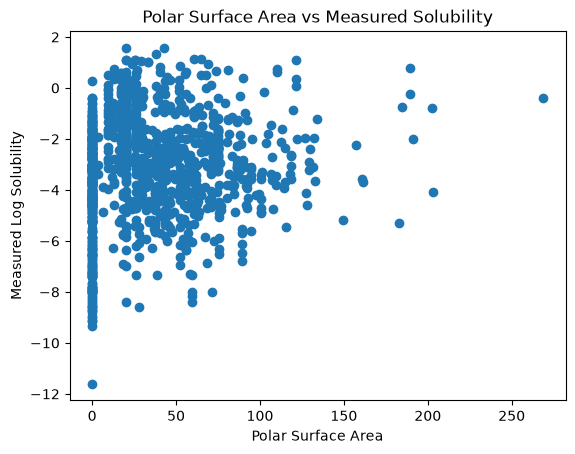

In [14]:
plt.scatter(
    df["Polar Surface Area"],
    df["measured log solubility in mols per litre"]
)

plt.xlabel("Polar Surface Area")
plt.ylabel("Measured Log Solubility")
plt.title("Polar Surface Area vs Measured Solubility")

plt.show()

In [15]:
df["Polar Surface Area"].corr(
    df["measured log solubility in mols per litre"]
).round(2)

np.float64(0.12)

**Observation:** The correlation coefficient between polar surface area and measured log solubility is approximately **0.12**, indicating a very weak positive linear relationship. This is consistent with the scatter plot, where no clear trend is visible. Therefore, polar surface area alone does not appear to strongly explain aqueous solubility in this dataset.

### H-Bond Donors vs Solubility

A box plot is used to compare the distribution of measured solubility across different numbers of hydrogen bond donors.

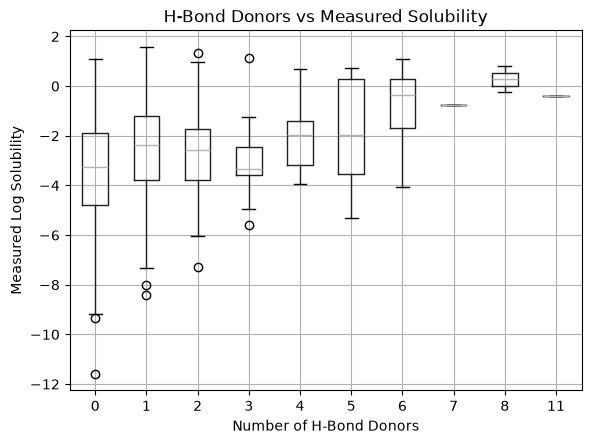

In [16]:
df.boxplot(
    column="measured log solubility in mols per litre",
    by="Number of H-Bond Donors"
)

plt.xlabel("Number of H-Bond Donors")
plt.ylabel("Measured Log Solubility")
plt.title("H-Bond Donors vs Measured Solubility")
plt.suptitle("")

plt.show()

In [17]:
df["Number of H-Bond Donors"].value_counts().sort_index(ascending=True)

Number of H-Bond Donors
0     635
1     307
2     137
3      22
4      11
5       6
6       6
7       1
8       2
11      1
Name: count, dtype: int64

**Observation:** The box plot suggests that measured log solubility may tend to increase as the number of H-bond donors increases. However, the groups are highly imbalanced. Most compounds contain 0–2 H-bond donors, while groups with higher donor counts contain very few observations. Therefore, the apparent trend at higher H-bond donor counts should be interpreted with caution.

### Number of Rings vs Solubility

In this section, we compare the average measured log solubility of compounds with different numbers of rings.

In [18]:
ring_solubility = df.groupby("Number of Rings")[
    "measured log solubility in mols per litre"
].mean()

ring_solubility

Number of Rings
0   -1.912486
1   -2.548288
2   -3.959548
3   -4.377543
4   -4.840317
5   -6.763625
6   -7.099250
7   -5.611333
8   -4.687000
Name: measured log solubility in mols per litre, dtype: float64

In [19]:
df["Number of Rings"].value_counts().sort_index()

Number of Rings
0    317
1    386
2    221
3    116
4     63
5     16
6      4
7      3
8      2
Name: count, dtype: int64

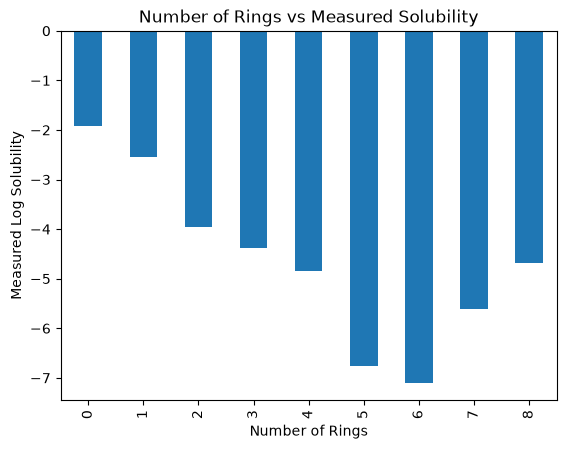

In [20]:
ring_solubility.plot(kind="bar")

plt.xlabel("Number of Rings")
plt.ylabel("Measured Log Solubility")
plt.title("Number of Rings vs Measured Solubility")

plt.show()

**Observation:** The average measured log solubility generally decreases as the number of rings increases, particularly from 0 to 5 rings. This suggests that compounds with more rings tend to have lower aqueous solubility. However, compounds with 6–8 rings are represented by very few observations, so the apparent changes in these groups should be interpreted with caution.

### Rotatable Bonds vs Solubility

In this section, we investigate how the number of rotatable bonds is associated with measured aqueous solubility.

In [21]:
df["Number of Rotatable Bonds"].unique()

array([ 7,  2,  4,  0,  1,  3, 11,  8,  5,  6,  9, 10, 15, 23, 14, 12, 16,
       13, 17])

In [22]:
df["Number of Rotatable Bonds"].value_counts().sort_index()

Number of Rotatable Bonds
0     361
1     232
2     174
3     102
4      86
5      57
6      40
7      22
8      24
9       9
10      6
11      1
12      4
13      2
14      3
15      1
16      2
17      1
23      1
Name: count, dtype: int64

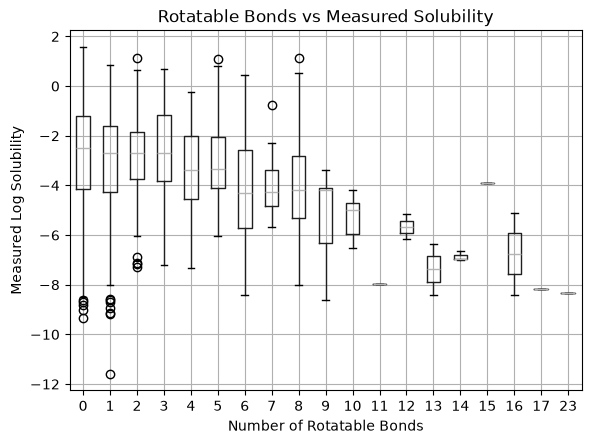

In [23]:
df.boxplot(
    column="measured log solubility in mols per litre",
    by="Number of Rotatable Bonds"
)

plt.xlabel("Number of Rotatable Bonds")
plt.ylabel("Measured Log Solubility")
plt.title("Rotatable Bonds vs Measured Solubility")
plt.suptitle("")

plt.show()

In [24]:
df["Number of Rotatable Bonds"].corr(
    df["measured log solubility in mols per litre"]
).round(2)

np.float64(-0.24)

**Observation:** The correlation coefficient between the number of rotatable bonds and measured log solubility is approximately **-0.24**, indicating a weak negative linear relationship. Compounds with more rotatable bonds tend to have slightly lower aqueous solubility, but the relationship is not strong. Therefore, the number of rotatable bonds alone does not appear to be a strong predictor of solubility.

### Correlation Matrix and Heatmap

A correlation matrix is used to examine the linear relationships among multiple molecular properties and measured solubility simultaneously.

In [25]:
selected_columns = df[[
    "Molecular Weight",
    "Polar Surface Area",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "measured log solubility in mols per litre"
]]

In [27]:
correlation_matrix = selected_columns.corr()

correlation_matrix

,Molecular Weight,Polar Surface Area,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,measured log solubility in mols per litre
Molecular Weight,1.000000,0.475440,0.254877,0.652521,0.396894,-0.640189
Polar Surface Area,0.475440,1.000000,0.755932,0.308606,0.286723,0.123210
Number of H-Bond Donors,0.254877,0.755932,1.000000,0.211087,0.077002,0.209429
Number of Rings,0.652521,0.308606,0.211087,1.000000,-0.136654,-0.512279
Number of Rotatable Bonds,0.396894,0.286723,0.077002,-0.136654,1.000000,-0.244256
measured log solubility in mols per litre,-0.640189,0.123210,0.209429,-0.512279,-0.244256,1.000000


In [29]:
import seaborn as sns

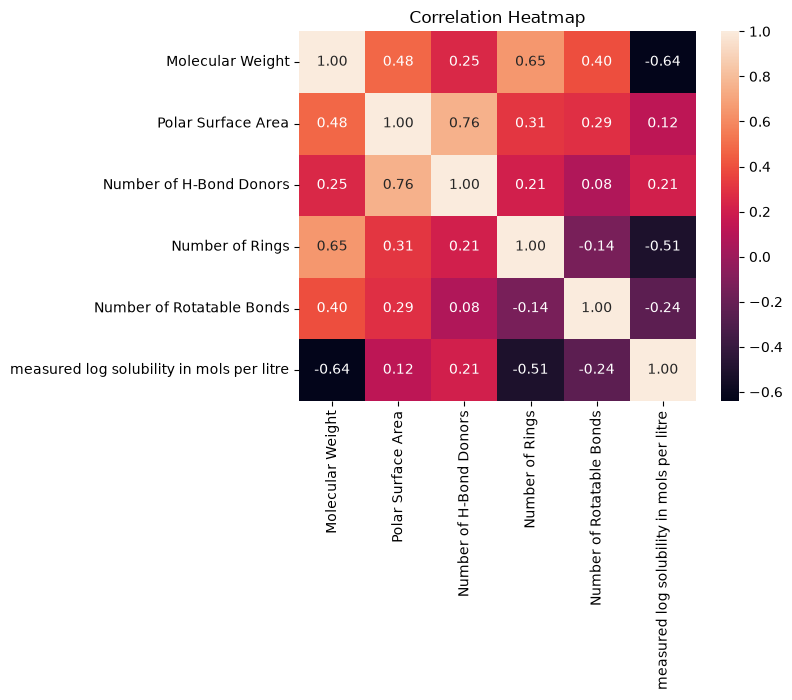

In [30]:
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

**Observation:** The correlation heatmap shows that molecular weight has the strongest negative correlation with measured log solubility (**-0.64**), followed by the number of rings (**-0.51**). Polar surface area and H-bond donors show weak positive correlations with solubility, while rotatable bonds show a weak negative correlation. Some molecular descriptors are also correlated with each other, particularly polar surface area and H-bond donors (**0.76**) and molecular weight and number of rings (**0.65**). These relationships suggest that molecular properties may interact and should not be interpreted independently.

### ESOL Predicted vs Measured Solubility

In this section, we compare the ESOL-predicted solubility values with the experimentally measured solubility values.

A strong agreement between predicted and measured values would indicate that the ESOL model captures the solubility patterns in the dataset reasonably well.

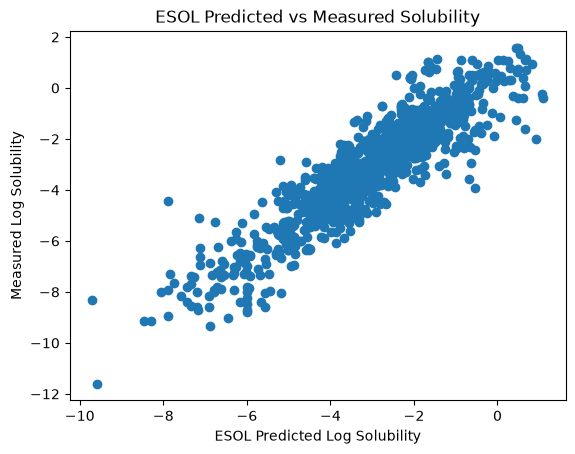

In [31]:
plt.scatter(
    df["ESOL predicted log solubility in mols per litre"],
    df["measured log solubility in mols per litre"]
)

plt.xlabel("ESOL Predicted Log Solubility")
plt.ylabel("Measured Log Solubility")
plt.title("ESOL Predicted vs Measured Solubility")
plt.show()

In [32]:
df["ESOL predicted log solubility in mols per litre"].corr(
    df["measured log solubility in mols per litre"]
).round(2)

np.float64(0.91)

**Observation:** The ESOL-predicted and experimentally measured log solubility values show a strong positive correlation (**r = 0.91**). This indicates that the ESOL predictions closely follow the overall trend of the experimental measurements. However, a high correlation does not necessarily mean that the predictions are perfectly accurate.

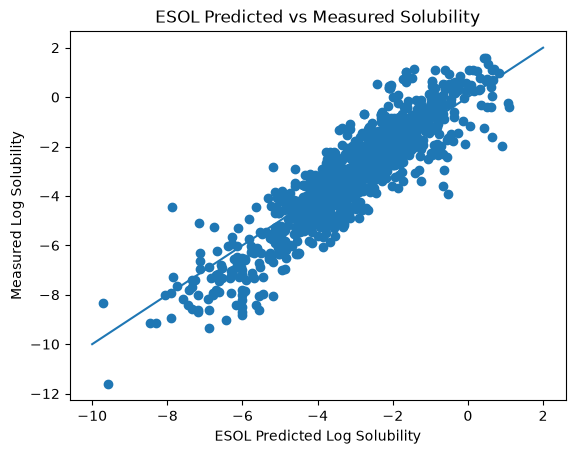

In [33]:
plt.scatter(
    df["ESOL predicted log solubility in mols per litre"],
    df["measured log solubility in mols per litre"]
)

plt.plot([-10, 2], [-10, 2])

plt.xlabel("ESOL Predicted Log Solubility")
plt.ylabel("Measured Log Solubility")
plt.title("ESOL Predicted vs Measured Solubility")
plt.show()

**Observation:** The ESOL-predicted and experimentally measured log solubility values show a strong positive correlation (**r = 0.91**). Most observations are distributed relatively close to the ideal prediction line (y = x), indicating good overall agreement between predicted and measured values. However, some compounds deviate noticeably from the ideal line, showing that the ESOL model does not predict every compound equally accurately. A high correlation indicates strong agreement in the overall trend but does not imply perfect predictive accuracy.

### Prediction Error Analysis

Prediction errors (residuals) are calculated to examine the differences between experimentally measured and ESOL-predicted solubility values.

In [34]:
df["Residual"] = (
    df["measured log solubility in mols per litre"]
    - df["ESOL predicted log solubility in mols per litre"]
)

In [35]:
df[[
    "ESOL predicted log solubility in mols per litre",
    "measured log solubility in mols per litre",
    "Residual"
]].head()

,ESOL predicted log solubility in mols per litre,measured log solubility in mols per litre,Residual
0,-0.974,-0.77,0.204
1,-2.885,-3.30,-0.415
2,-2.579,-2.06,0.519
3,-6.618,-7.87,-1.252
4,-2.232,-1.33,0.902


In [36]:
df["Absolute Error"] = df["Residual"].abs()

In [37]:
df[["Residual", "Absolute Error"]].head()

,Residual,Absolute Error
0,0.204,0.204
1,-0.415,0.415
2,0.519,0.519
3,-1.252,1.252
4,0.902,0.902


In [38]:
df["Absolute Error"].mean()

np.float64(0.6978617021276595)

In [39]:
mae = df["Absolute Error"].mean().round(2)
mae

np.float64(0.7)

**Observation:** The Mean Absolute Error (MAE) of the ESOL predictions is approximately **0.70 logS units**. This means that, on average, the predicted log solubility values differ from the experimentally measured values by about 0.70 logS units.

In [40]:
df["Squared Error"] = df["Residual"] ** 2

In [41]:
df[["Residual", "Squared Error"]].head()

,Residual,Squared Error
0,0.204,0.041616
1,-0.415,0.172225
2,0.519,0.269361
3,-1.252,1.567504
4,0.902,0.813604


In [43]:
import numpy as np

In [46]:
mse = df["Squared Error"].mean()
rmse = np.sqrt(mse)

rmse

np.float64(0.9101322725549837)

In [47]:
rmse = np.sqrt(df["Squared Error"].mean()).round(2)
rmse

np.float64(0.91)

**Observation:** The ESOL model has a Mean Absolute Error (MAE) of approximately **0.70 logS units** and a Root Mean Squared Error (RMSE) of approximately **0.91 logS units**. The RMSE is higher than the MAE, suggesting that some compounds have relatively large prediction errors.

### Residual Distribution

The distribution of residuals is examined to understand the prediction errors of the ESOL model.

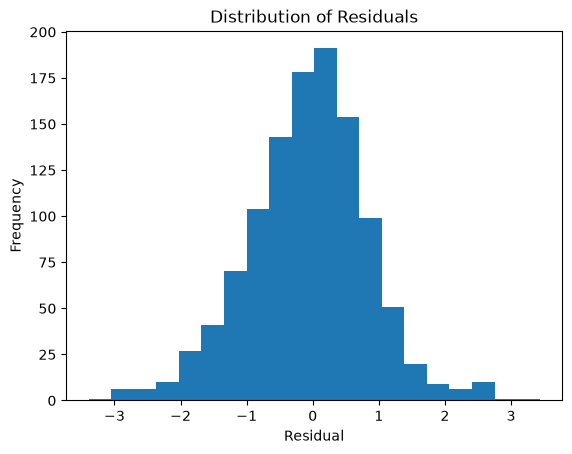

In [48]:
plt.hist(df["Residual"], bins=20)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

In [49]:
df["Residual"].mean().round(2)

np.float64(-0.06)

**Observation:** The residuals are approximately centered around zero, with a mean residual of **-0.06 logS units**. This suggests that the ESOL model does not show a strong systematic tendency to overpredict or underpredict solubility. Most residuals are concentrated near zero, although a small number of relatively large prediction errors are present.

## 4. Machine Learning — Solubility Prediction

In this section, a machine learning model will be developed to predict measured aqueous solubility using molecular descriptors.